In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras import Sequential
from tensorflow.keras import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import plot_model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Input, Concatenate, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from concurrent.futures import ThreadPoolExecutor
from keras.preprocessing.image import img_to_array, load_img
from sklearn.preprocessing import LabelBinarizer
from keras.utils import to_categorical

import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
import threading
import numpy as np
import pandas as pd
import cv2
import os
import gc


tf.keras.backend.clear_session()

2024-03-12 16:13:36.994828: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-12 16:13:36.994958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-12 16:13:37.128896: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/tmp/ipykernel_34/3569246210.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(subfolders))


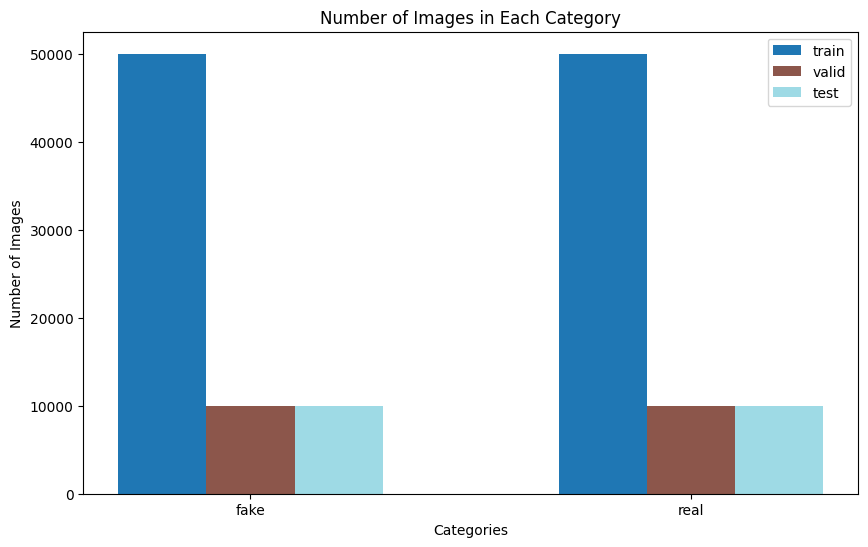

In [2]:
#plot 1
folder_path = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
subfolders = ["train", "valid", "test"]


# Dictionary to store the counts
counts = {subfolder: {} for subfolder in subfolders}

# Loop through each subfolder
for subfolder in subfolders:
    subfolder_path = os.path.join(folder_path, subfolder)
    categories = os.listdir(subfolder_path)
    for category in categories:
        category_path = os.path.join(subfolder_path, category)
        file_count = len(os.listdir(category_path))
        counts[subfolder][category] = file_count

colors = plt.cm.get_cmap('tab20', len(subfolders))
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
bar_positions = np.arange(len(counts[subfolders[0]]))

for i, subfolder in enumerate(subfolders):
    category_counts = counts[subfolder]
    ax.bar(bar_positions + i * bar_width, category_counts.values(), bar_width, label=subfolder, color=colors(i))

ax.set_xlabel('Categories')
ax.set_ylabel('Number of Images')
ax.set_title('Number of Images in Each Category')
ax.set_xticks(bar_positions + (len(subfolders) - 1) * bar_width / 2)
ax.set_xticklabels(category_counts.keys())
ax.legend()

plt.show()

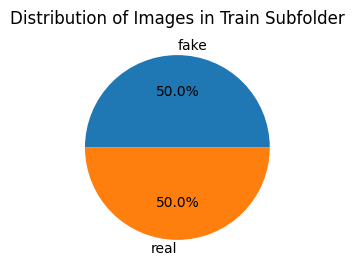

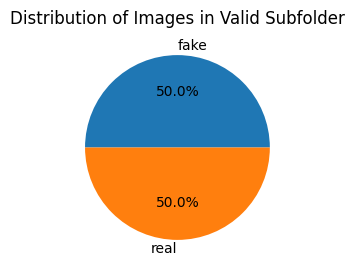

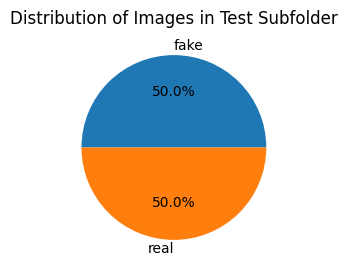

In [3]:
# plot 2
for subfolder in subfolders:
    subfolder_path = os.path.join(folder_path, subfolder)
    categories = os.listdir(subfolder_path)
    counts = []
    labels = []
    for category in categories:
        category_path = os.path.join(subfolder_path, category)
        file_count = len(os.listdir(category_path))
        counts.append(file_count)
        labels.append(category)

    # Plotting
    plt.figure(figsize=(3, 3))
    plt.pie(counts, labels=labels, autopct='%1.1f%%')
    plt.title(f'Distribution of Images in {subfolder.capitalize()} Subfolder')
    plt.show()

In [4]:
train_datagen = ImageDataGenerator(rescale=1/255)
val_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train",
    batch_size = 32,
    target_size = (256, 256),
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid",
    batch_size = 32,
    target_size = (256, 256),
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test",
    batch_size= 32,
    target_size = (256, 256),
    class_mode='binary',
    shuffle=True
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [6]:
set(train_generator.labels)

{0, 1}

In [7]:
set(val_generator.labels)

{0, 1}

In [8]:
set(test_generator.labels)

{0, 1}

In [14]:
num_classes = 2

input_data = Input(shape=(256, 256, 3))

resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_data)
resnet_output = resnet_base.output
resnet_output = Dropout(0.3)(resnet_output)

for layer in resnet_base.layers:
    layer.name = 'resnet_' + layer.name

densenet_base = DenseNet121(weights='imagenet', include_top=False, input_tensor=input_data)
densenet_output = densenet_base.output
densenet_output = Dropout(0.3)(densenet_output)


for layer in densenet_base.layers:
    layer.name = 'densenet_' + layer.name

concatenated = Concatenate(axis=-1)([resnet_output, densenet_output])


x = GlobalAveragePooling2D()(concatenated)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

ensemble_model = Model(inputs=input_data, outputs=output)

# for layer in resnet_base.layers:
#     layer.trainable = False

In [15]:
# # Model Drawing 3
# plot_model(ensemble_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [16]:
# # Model Summary
# ensemble_model.summary()

In [17]:
lr_callbacks = ReduceLROnPlateau(factor=0.5, patience=2)
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

ensemble_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
hist = ensemble_model.fit(
    train_generator,
    epochs=2,
    callbacks=[lr_callbacks, early_stopping],
    validation_data=val_generator
)

Epoch 1/2


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1710260545.122319     125 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1710260545.391022     125 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8857 - loss: 0.2850

W0000 00:00:1710261730.816118     124 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1601s 428ms/step - accuracy: 0.8857 - loss: 0.2849 - val_accuracy: 0.9157 - val_loss: 0.2469 - learning_rate: 0.0010
Epoch 2/2
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1249s 399ms/step - accuracy: 0.9756 - loss: 0.0682 - val_accuracy: 0.9707 - val_loss: 0.0786 - learning_rate: 0.0010


In [50]:
predict = ensemble_model.evaluate(test_generator)

625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.9694 - loss: 0.0797


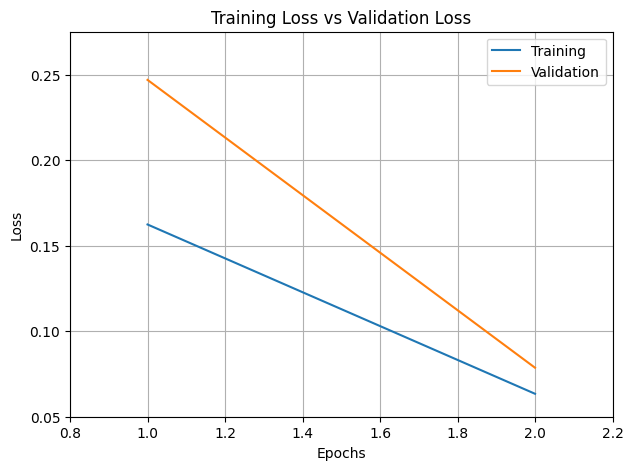

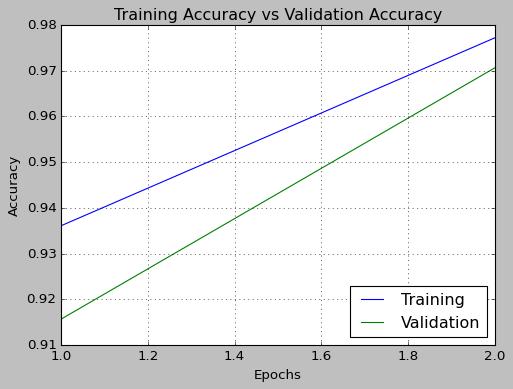

In [20]:
train_loss = hist.history['loss']
val_loss = hist.history['val_loss']
train_acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

plt.figure(1, figsize=(7, 5))
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend(['Training', 'Validation'])
plt.grid(True)
plt.style.use('classic')

plt.figure(2, figsize=(7, 5))
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.grid(True)
plt.style.use('classic')

plt.show()

In [21]:
model_json = ensemble_model.to_json()
with open("AAOHybrid_model.json", "w") as json_file:
    json_file.write(model_json)
    
ensemble_model.save_weights("AAOHybrid_final.weights.h5")

In [22]:
from tensorflow.keras.models import model_from_json

with open("AAOHybrid_model.json", "r") as json_file:
    loaded_model_json = json_file.read()
loaded_model = model_from_json(loaded_model_json)

loaded_model.load_weights("AAOHybrid_final.weights.h5")

In [175]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_faces_and_predict(images_dir, face_cascade, loaded_model, threshold, offset):
    random.seed(10)
    image_paths = [os.path.join(images_dir, img_name) for img_name in os.listdir(images_dir)]
    random_image_paths = random.sample(image_paths, 5)

    for img_path in random_image_paths:
        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5, minSize=(30, 30))

        for (x, y, w, h) in faces:
            x_offset, y_offset = offset, offset

            x_offset = min(x_offset, x)
            y_offset = min(y_offset, y)

            x_expanded = max(0, x - x_offset)
            y_expanded = max(0, y - y_offset)
            w_expanded = min(img.shape[1] - x_expanded, w + 2 * x_offset)
            h_expanded = min(img.shape[0] - y_expanded, h + 2 * y_offset)

            face = img[y_expanded:y_expanded+h_expanded, x_expanded:x_expanded+w_expanded]

            face = cv2.resize(face, (256, 256))
            face = face / 255.0
            face = np.expand_dims(face, axis=0)

            prediction = loaded_model.predict(face)
            print(prediction)
            label = f"Fake {round(prediction[0][0], 3)}" if prediction[0][0] > threshold else f"Real {round(prediction[0][1], 3)}"
            color = (0, 0, 255) if label == f"Fake {round(prediction[0][0], 3)}" else (0, 255, 0)
            cv2.putText(img, label, (x_expanded, y_expanded-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            cv2.rectangle(img, (x_expanded, y_expanded), (x_expanded+w_expanded, y_expanded+h_expanded), color, 2)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.84610355 0.1538965 ]]


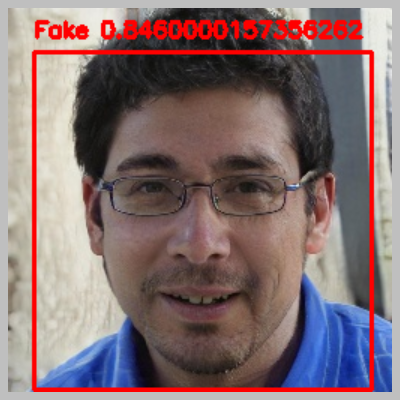

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.54462874 0.45537126]]


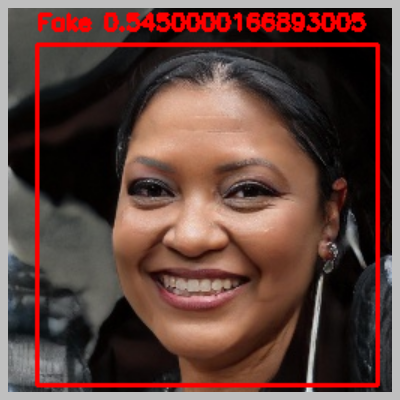

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.98612595 0.01387405]]


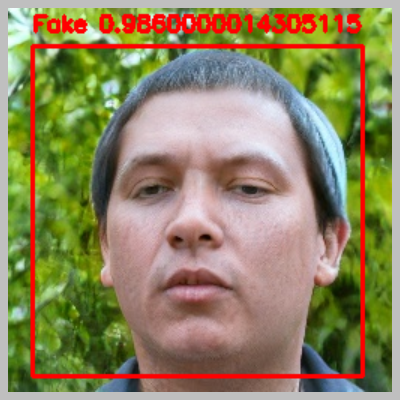

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.773831   0.22616902]]


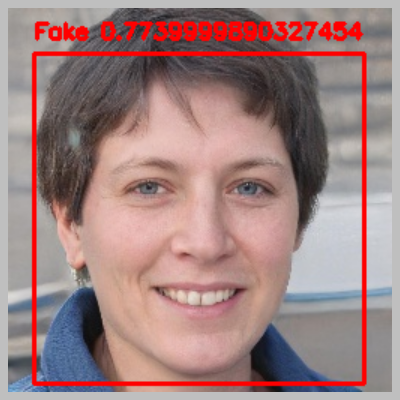

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[9.9965036e-01 3.4964335e-04]]


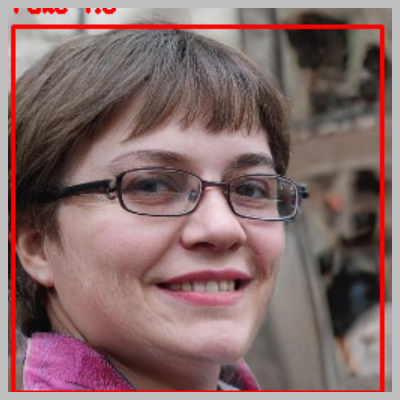

In [177]:
images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/fake/'

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
detect_faces_and_predict(images_dir, face_cascade, loaded_model, 0.50, 25)

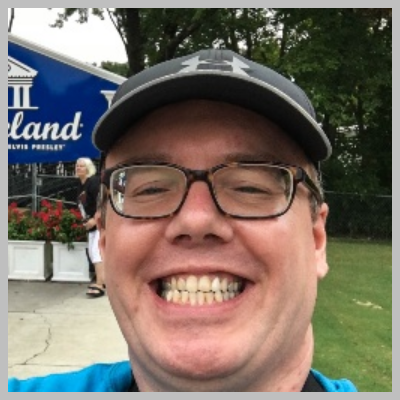

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.07943199 0.920568  ]]


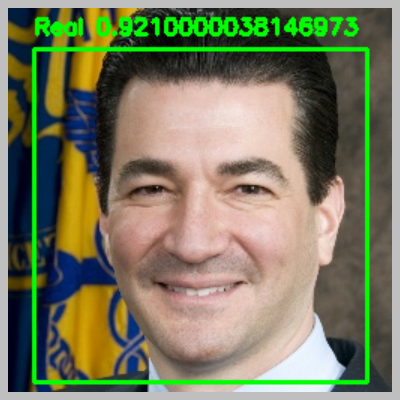

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.20000814 0.7999919 ]]


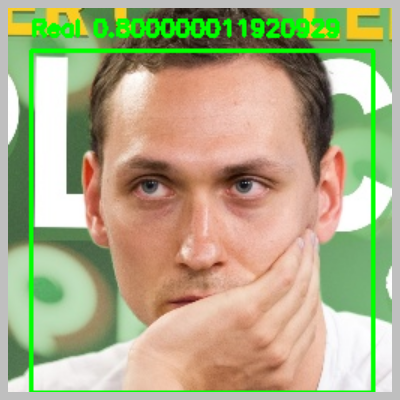

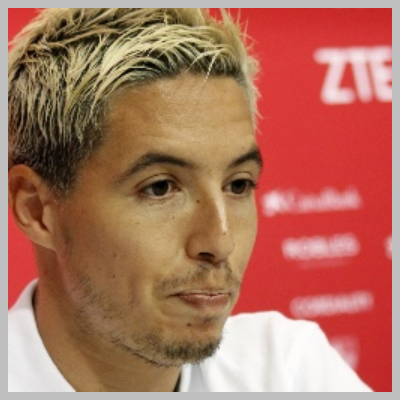

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.02603095 0.973969  ]]


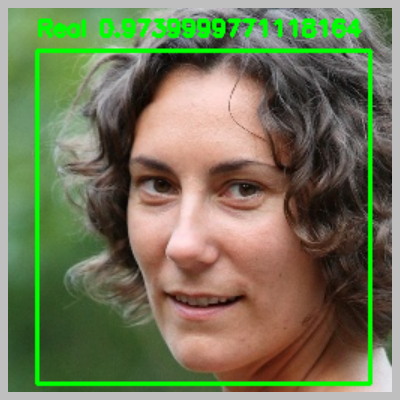

In [179]:
images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/real/'

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
detect_faces_and_predict(images_dir, face_cascade, loaded_model, 0.5, 25)